# FEATURE MATCHING

### Advanced methods for detecting matching objects, even if target image is not shown exactly the same.

### METHODS:
1. Brute-Force Matching with ORB Descriptors.
2. Brute-Force Matching with SIFT Descriptors and Radio Test.
3. FLANN based Matcher. 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def display(img, cmap='gray'):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

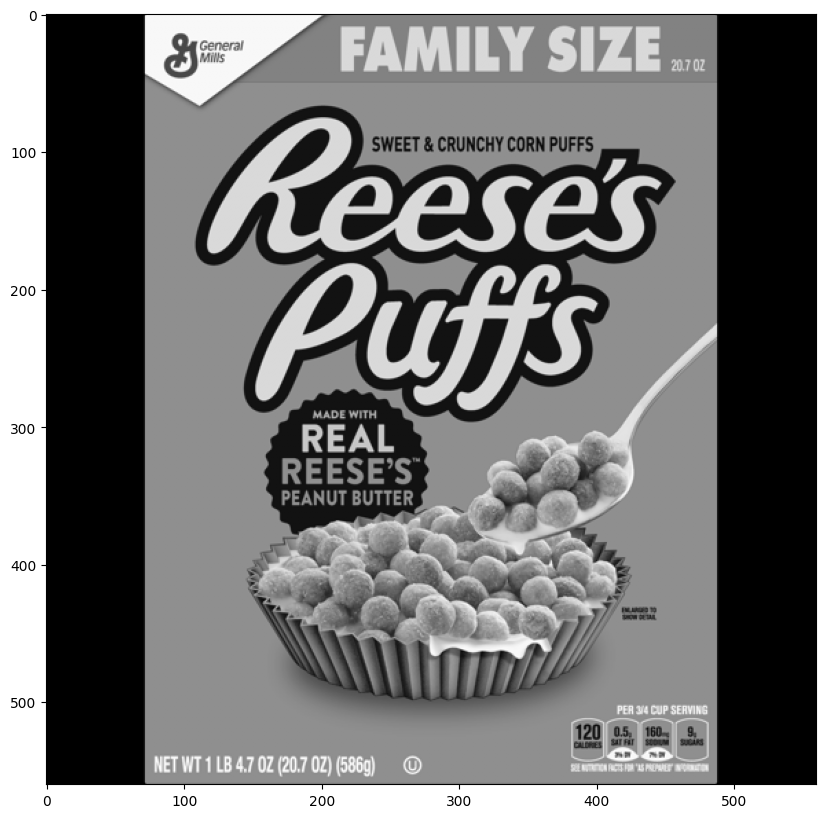

In [3]:
reeses = cv2.imread('../DATA/reeses_puffs.png', 0)
display(reeses)

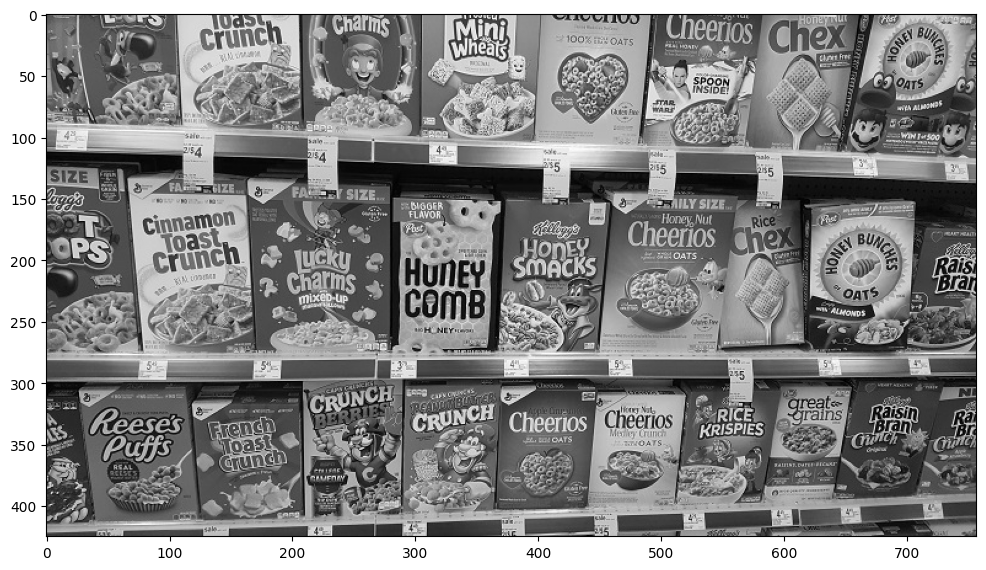

In [4]:
cereals = cv2.imread('../DATA/many_cereals.jpg', 0)
display(cereals)

### 1. ORB Detector

In [5]:
# ORB Detectors
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(reeses, None)
kp2, des2 = orb.detectAndCompute(cereals, None)

In [11]:
# Brute force Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

In [12]:
single_match = matches[0]
single_match.distance

56.0

In [15]:
len(matches)

139

In [13]:
matches = sorted(matches, key=lambda x:x.distance)

In [14]:
single_match = matches[0]
single_match.distance

42.0

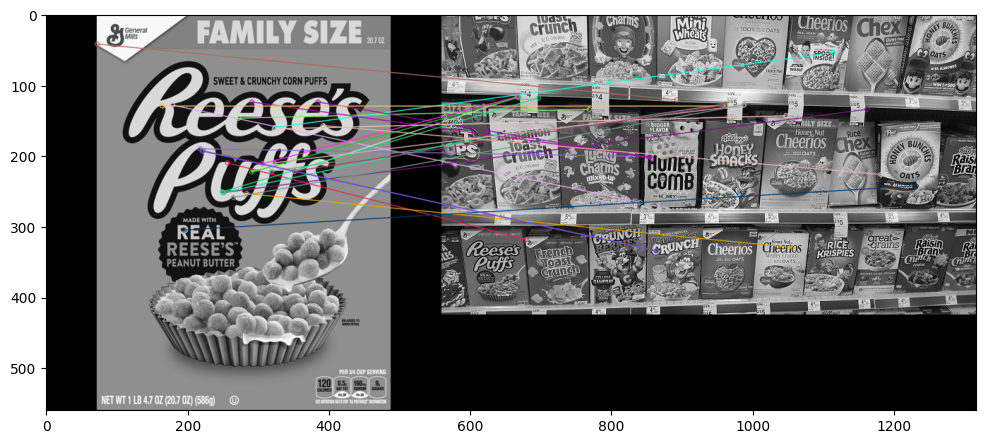

In [17]:
reeses_matches = cv2.drawMatches(reeses, kp1, cereals, kp2, matches[:25], None, flags=2)
display(reeses_matches)

# ***Not working advancely as we require, we need more sophasticated methods for such target feature matching. 

### 2. SIFT Descriptor (Scale Invarient Feature Transform)

In [19]:
reeses = cv2.imread('../DATA/reeses_puffs.png', 0)
cereals = cv2.imread('../DATA/many_cereals.jpg', 0)

In [31]:
# SIFT Descriptor creation
sift = cv2.SIFT_create()

# Computing
kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

In [32]:
# Brute Force Matching
bf = cv2.BFMatcher()

In [33]:
matches = bf.knnMatch(des1, des2, k=2)
matches

((< cv2.DMatch 0000018082214E30>, < cv2.DMatch 0000018082214310>),
 (< cv2.DMatch 0000018082215A90>, < cv2.DMatch 0000018082214990>),
 (< cv2.DMatch 0000018082215BF0>, < cv2.DMatch 0000018082215730>),
 (< cv2.DMatch 0000018082217670>, < cv2.DMatch 00000180822144B0>),
 (< cv2.DMatch 0000018082214570>, < cv2.DMatch 0000018082215E90>),
 (< cv2.DMatch 0000018082215550>, < cv2.DMatch 0000018082215B50>),
 (< cv2.DMatch 0000018082214E70>, < cv2.DMatch 0000018082214DF0>),
 (< cv2.DMatch 0000018082214BB0>, < cv2.DMatch 00000180822148F0>),
 (< cv2.DMatch 0000018082214AF0>, < cv2.DMatch 0000018082214590>),
 (< cv2.DMatch 0000018082215AB0>, < cv2.DMatch 00000180822156D0>),
 (< cv2.DMatch 0000018082215650>, < cv2.DMatch 0000018082215490>),
 (< cv2.DMatch 0000018082215070>, < cv2.DMatch 0000018082215330>),
 (< cv2.DMatch 0000018082215B70>, < cv2.DMatch 00000180822151B0>),
 (< cv2.DMatch 00000180822152D0>, < cv2.DMatch 0000018082215290>),
 (< cv2.DMatch 0000018082215210>, < cv2.DMatch 00000180822159F

In [34]:
# finding the good matches
# LESS DIST. == BETTER MATCHES
good = []

for match1, match2 in matches:
    # If match1 distance is less than 75% match2 distance
    # then descriptors was a good match and store in good list.
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [35]:
len(good)

79

In [36]:
len(matches)

1501

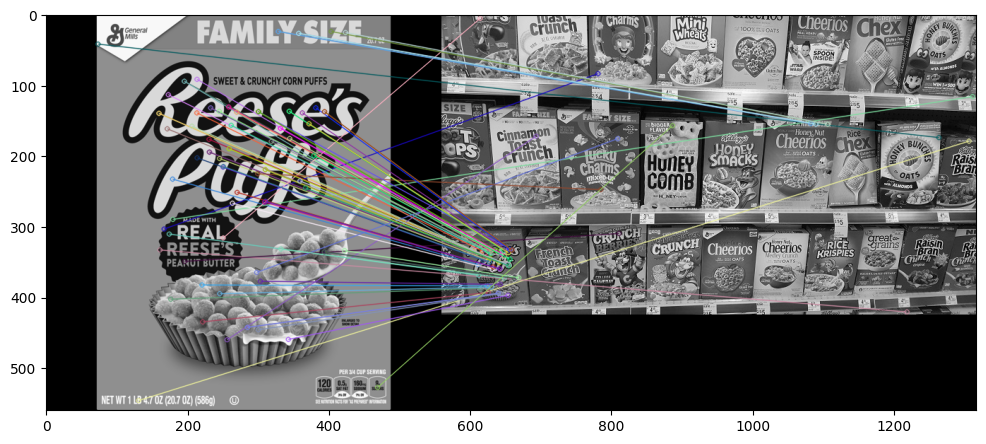

In [37]:
sift_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good, None, flags=2)
display(sift_matches)

In [38]:
# SIFT Descriptor creation
sift = cv2.SIFT_create()

# Computing
kp1, des1 = sift.detectAndCompute(reeses, None)
kp2, des2 = sift.detectAndCompute(cereals, None)

### FLANN (Fast Library for Approximates Nearest Neighbours)

In [39]:
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

In [41]:
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

In [49]:
matchesMask = [[0,0] for i in range(len(matches))]
matchesMask

[[0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 [0, 0],
 

In [52]:
# Taking out the best matches
# good = []

for i, (match1, match2) in enumerate(matches):
    if match1.distance < 0.7*match2.distance:
        # good.append([match1])
        matchesMask[i] = [1,0]

In [56]:
draw_params = dict(matchColor=(0,255,0),
                  singlePointColor=(255, 0, 0),
                  matchesMask=matchesMask,
                  flags=2)

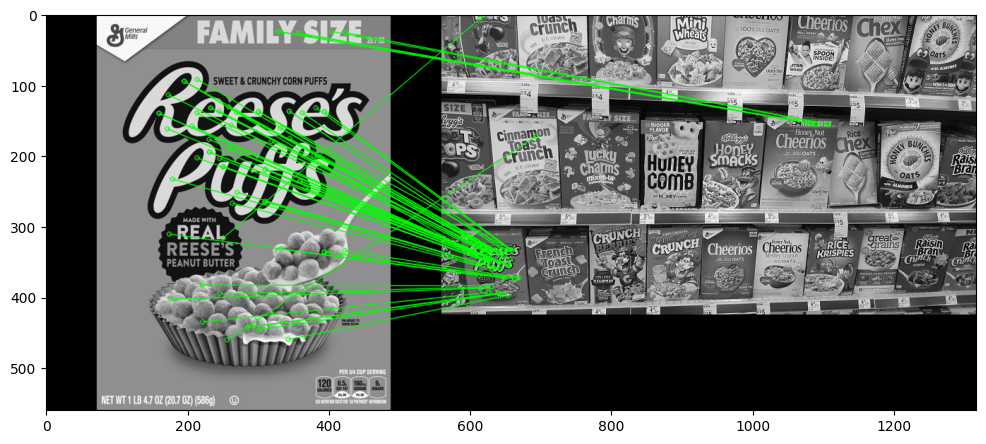

In [57]:
flann_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, matches, None, **draw_params)
display(flann_matches)